In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "adult"
namex = "Adult"

d = 14

###knn
graphsx = np.load("../graphs/"+name+"_knn_random.npy", allow_pickle=True)

## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/adult_knn_graphsummary.npy")
randomgraphsinfo


,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Adult (14),1,328,46,10,36,1.0,0.213415,0.786585,7.130435,0.031998,0.006694,0.025304,70,258,0,0,0
1,Adult (14),2,328,49,12,37,2.0,0.484756,1.515244,13.387755,0.111602,0.029089,0.082513,15,184,0,0,1
2,Adult (14),3,328,49,12,37,3.0,0.777439,2.222561,20.081633,0.270381,0.084564,0.185817,4,121,0,0,2
3,Adult (14),4,328,49,12,37,4.0,1.076220,2.923780,26.775510,0.487283,0.173249,0.314034,2,86,0,0,3
4,Adult (14),5,328,49,12,37,5.0,1.405488,3.594512,33.469388,0.764768,0.300608,0.464161,1,61,0,0,4
5,Adult (14),6,328,49,12,37,6.0,1.725610,4.274390,40.163265,1.108693,0.453662,0.655031,0,44,0,0,5
6,Adult (14),7,328,49,12,37,7.0,2.009146,4.990854,46.857143,1.502890,0.601197,0.901693,0,33,0,0,6
7,Adult (14),8,328,49,12,37,8.0,2.347561,5.652439,53.551020,1.963527,0.794119,1.169408,0,19,0,0,7
8,Adult (14),9,328,49,12,37,9.0,2.689024,6.310976,60.244898,2.481875,1.012643,1.469232,0,12,0,0,8
9,Adult (14),10,328,49,12,37,10.0,2.957317,7.042683,66.938776,3.037052,1.209797,1.827254,0,10,0,0,9


## Compute and evaluate results for the targeted intervention model

In [4]:
summary_dfx = scripts.analytics.compute_itm_results(datasgraphs = graphsx,
                                                      thresh=False,
                                                      dsetname = name,
                                                      dsetdim = d)

summary_dfx.to_csv("./im_results/"+name+"_boost_results_knn.csv", index=False)
summary_dfx.head(10)

,K,B,Sg,Sg_lbls,F(Sg),Sgb,Sgb_lbls,F(Sgb)b4B,F(Sgb),Boostedgb,...,Boostedbg,usedBbudgetbg,kmax,n,m,greedyTime,greedyBoostTime,boostGreedyTime,dataset,graphid
0,1,4,{},{},70.0,{},{},70.0,74.0,"[0, 1, 2, 3]",...,"[0, 1, 2, 3]",4,1,328,46,0.054603,0.052609,0.050813,adult (14),0
1,1,3,{},{},70.0,{},{},70.0,73.0,"[0, 1, 2]",...,"[0, 1, 2]",3,1,328,46,0.052093,0.052923,0.048984,adult (14),0
2,1,2,{},{},70.0,{},{},70.0,72.0,"[0, 1]",...,"[0, 1]",2,1,328,46,0.054064,0.061279,0.082334,adult (14),0
3,1,1,{},{},70.0,{},{},70.0,71.0,[0],...,[0],1,1,328,46,0.062742,0.060423,0.056338,adult (14),0
4,1,0,{},{},70.0,{},{},70.0,70.0,[],...,[],0,1,328,46,0.063586,0.119159,0.068190,adult (14),0
5,2,4,{},{},70.0,{},{},70.0,74.0,"[0, 1, 2, 3]",...,"[0, 1, 2, 3]",4,1,328,46,0.107705,0.058454,0.063950,adult (14),0
6,2,3,{},{},70.0,{},{},70.0,73.0,"[0, 1, 2]",...,"[0, 1, 2]",3,1,328,46,0.091405,0.122797,0.073791,adult (14),0
7,2,2,{},{},70.0,{},{},70.0,72.0,"[0, 1]",...,"[0, 1]",2,1,328,46,0.088649,0.056899,0.080320,adult (14),0
8,2,1,{},{},70.0,{},{},70.0,71.0,[0],...,[0],1,1,328,46,0.059344,0.051646,0.053398,adult (14),0
9,2,0,{},{},70.0,{},{},70.0,70.0,[],...,[],0,1,328,46,0.106819,0.067805,0.067819,adult (14),0


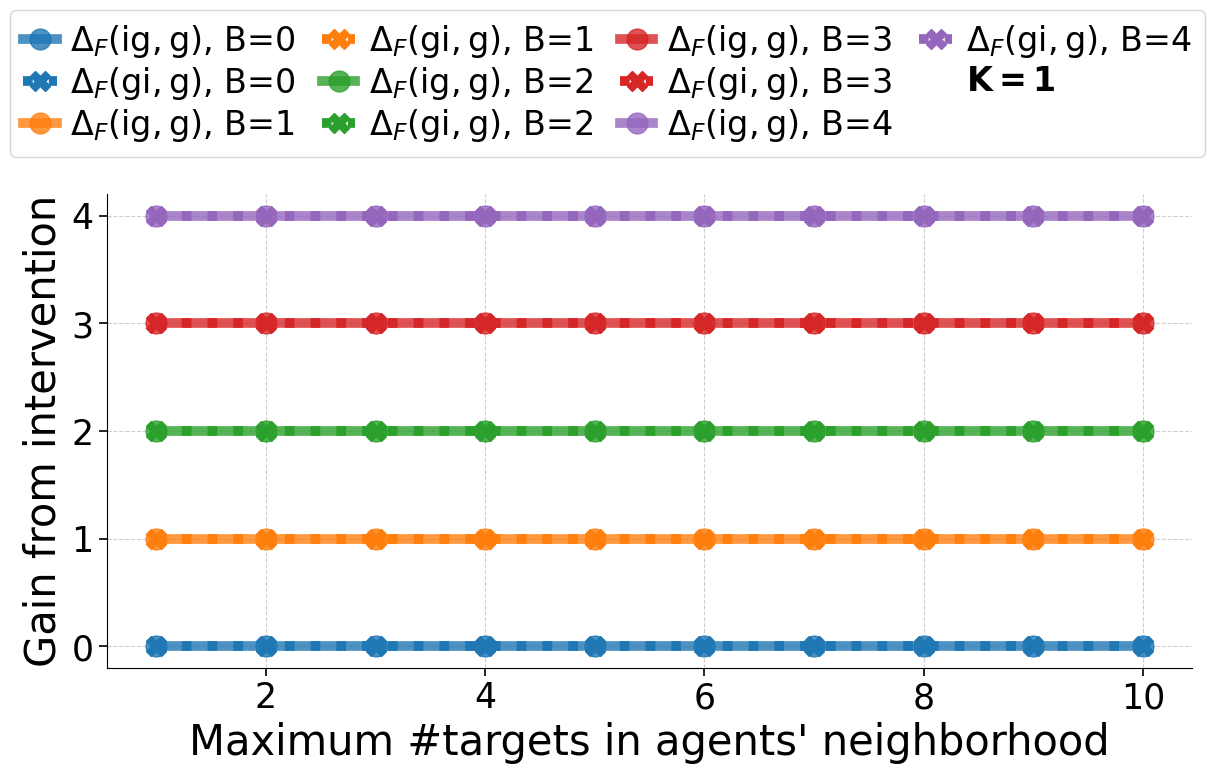

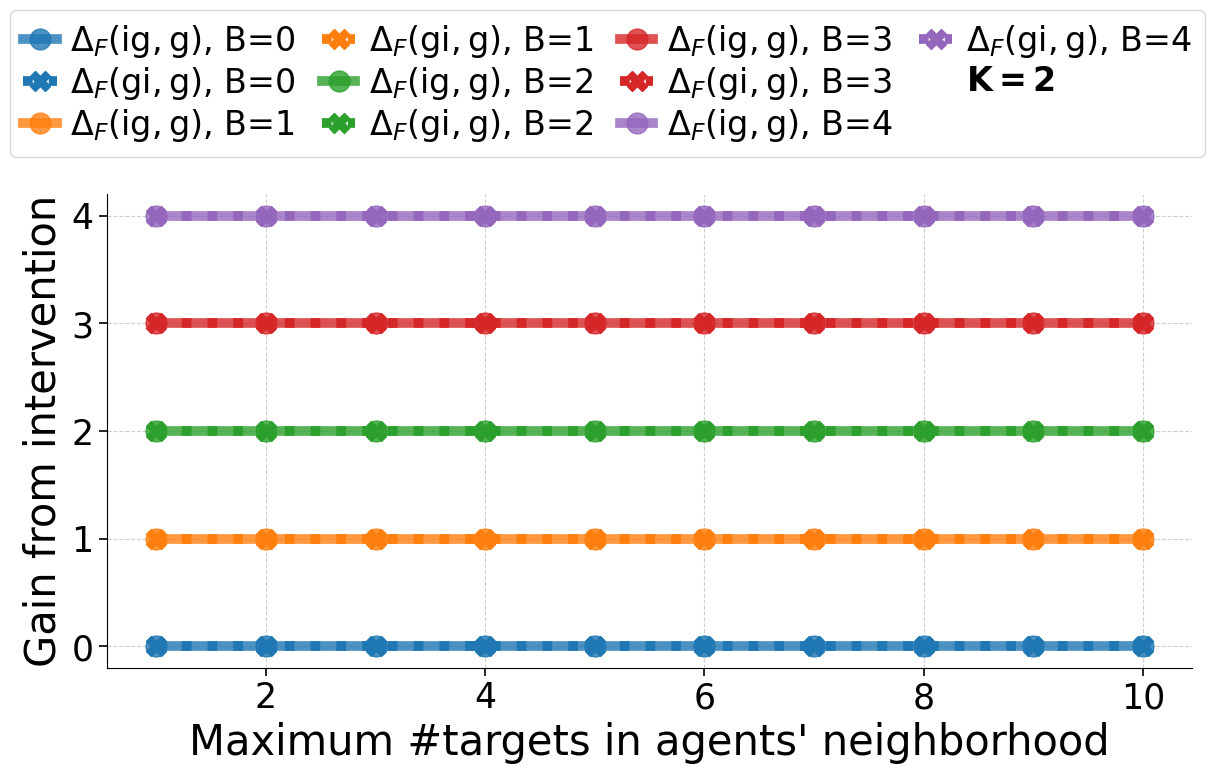

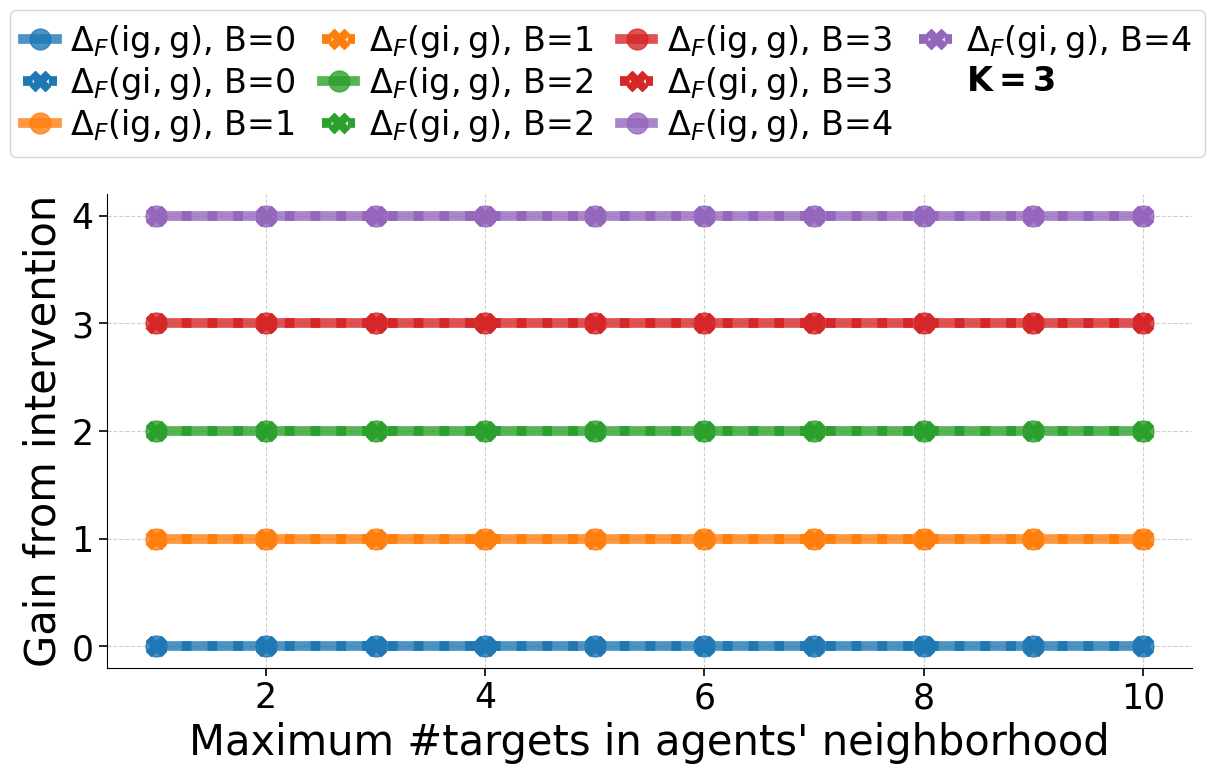

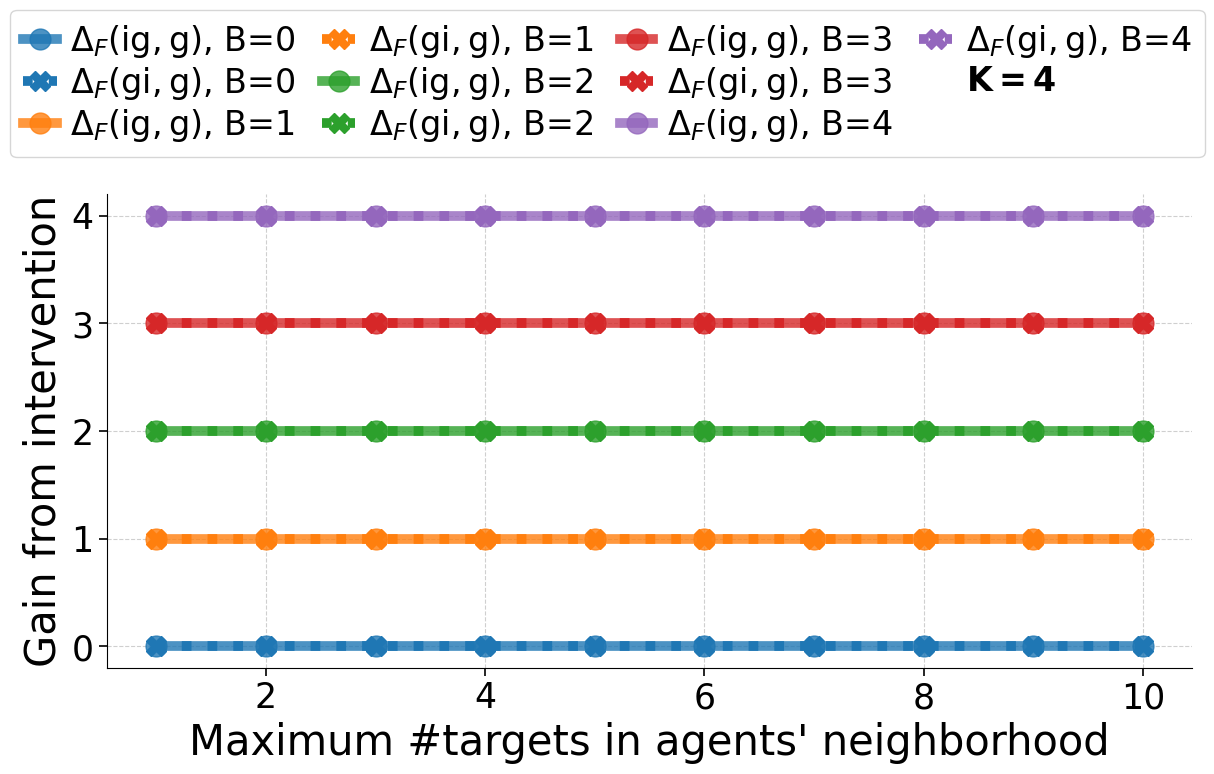

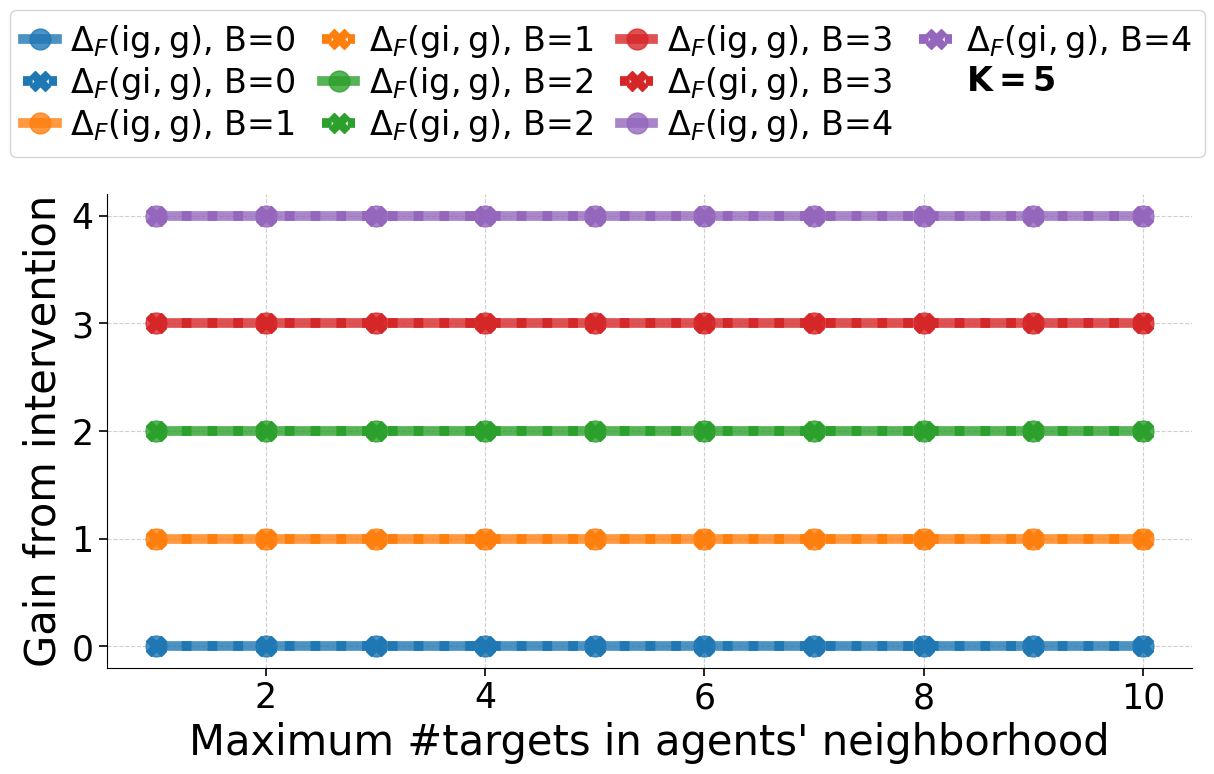

In [5]:
scripts.analytics.plot_intm_results(resdf = summary_dfx,
                                      thresh=False,
                                      save_as = "./im_results/figures/"+name+"_imb4aftersm_results_knn")